## This cell imports libraries for deep learning 

In [40]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import KerasTensor
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print("Imports successful!")

TensorFlow version: 2.21.0
Imports successful!


## Creating a Binary Classification Dataset

This filters the original dataset to create a new directory containing only the two classes needed for binary classification: healthy and bacterial_blight.

**Source** : cassava_small

**Destination** : cassava_binary

and then it wipes out any old versions of the destination folder and copies over the specific classes we need, ensuring we start with a clean, focused dataset.

In [29]:
import os
import shutil

original_data_dir = "cassava_small"
binary_data_dir = "cassava_binary"

classes_to_keep = ["healthy", "bacterial_blight"]

# remove old binary folder if it exists
if os.path.exists(binary_data_dir):
    shutil.rmtree(binary_data_dir)

os.makedirs(binary_data_dir, exist_ok=True)

for cls in classes_to_keep:
    src = os.path.join(original_data_dir, cls)
    dst = os.path.join(binary_data_dir, cls)
    shutil.copytree(src, dst)

print("Binary dataset created.")
print("Classes:", os.listdir(binary_data_dir))

Binary dataset created.
Classes: ['healthy', 'bacterial_blight']


## checking class Distribution

This step loops through the newly created folders to confirm that the data transfer was successful and to check the balance between our classes.

**Process**: Iterates through each class in the binary directory.

**Output**: Prints the specific number of images found in both the healthy and bacterial_blight folders.

**Action** : Provides a quick headcount so we can spot any data imbalances right away before moving on to training.

In [30]:
for cls in sorted(os.listdir(binary_data_dir)):
    cls_path = os.path.join(binary_data_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")

bacterial_blight: 200 images
healthy: 200 images


In [31]:
data_dir = "cassava_binary"

In [32]:
print("binary class", sorted(os.listdir(data_dir)))

binary class ['bacterial_blight', 'healthy']


## Visualizing the Dataset: Random Samples inspection

This block pulls a few random examples from each class to give us a first-hand look at the actual image quality and labeling.

**Process**: Grabs 4 random images per class and organizes them into a clean grid.

**Purpose**: Helps us manually verify that the labels match the images and check for any obvious lighting or quality issues.

**Action**: Generates a quick visual gallery, making it easy to confirm that our input data is ready for the model.


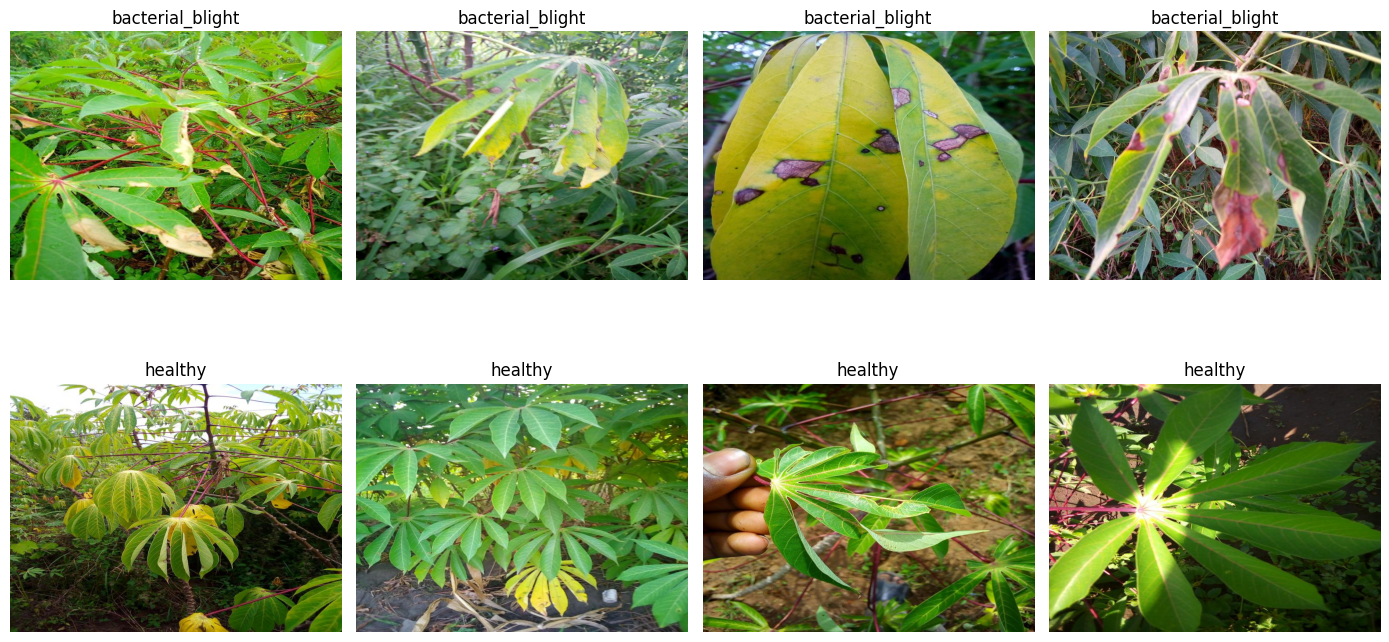

In [33]:
import math

classes = sorted(os.listdir(data_dir))
samples_per_class = 4
total_images = len(classes) * samples_per_class

cols = 4
rows = math.ceil(total_images / cols)

plt.figure(figsize=(14, 4 * rows))

plot_idx = 1
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = [
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ]

    selected = random.sample(images, min(len(images), samples_per_class))

    for img_name in selected:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

## Data preprocessing: Scaling, Augumentation and Loading 

This step sets up the ImageDataGenerators, which handle the heavy lifting of transforming our raw images into ready-to-train tensors.

**Normalization**: Rescales pixel values to the range, helping the model converge much faster.

**Augmentation**: Applies random transformations (rotation, zoom, flips) to the training set, forcing the model to learn general features rather than specific orientations.

**Splitting**: Automatically carves out of the data for validation to monitor performance on unseen images.
Action: Creates the train_data and val_data generators, effectively turning our folder structure into a stream of processed batches for training.

In [34]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


## Mapping Labels: Identifying class indices

This simple check confirms how the generator has numerically encoded our text labels, which is essential for interpreting the model's final predictions.

**Process**: Accesses the class_indices dictionary from the training generator.

**Purpose**: Maps folder names (like healthy) to their assigned integers (0 or 1).

**Action**: Provides the "decoder key" we’ll need later to translate the model's numerical output back into human-readable categories.


In [35]:
print("class indices:", train_data.class_indices)

class indices: {'bacterial_blight': 0, 'healthy': 1}


## Model Architecture: Transfer learning with mobileNetV2

This block defines the "brain" of our project. Instead of starting from scratch, we’re using Transfer Learning to leverage a pre-trained model that already knows how to recognize shapes and textures.

**The Base**: Loads MobileNetV2, a lightweight model trained on millions of images (ImageNet), with its top layers removed so we can add our own.

**Freezing**: Sets trainable = False to "freeze" the pre-trained weights, ensuring we don't ruin the existing knowledge while we train our custom layers.

**Custom Head**: Adds a GlobalAveragePooling layer to condense the data, followed by a Dense layer for reasoning and Dropout to prevent the model from over-relying on specific pixels (reducing overfitting).

**Output**: Ends with a 2-unit Softmax layer to give us a clear probability for our two classes: healthy or bacterial_blight.

In [36]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

## Mobile compili

In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cassava_binary_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [42]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5114 - loss: 1.2886
Epoch 1: val_accuracy improved from None to 0.55000, saving model to best_cassava_binary_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 509ms/step - accuracy: 0.5125 - loss: 1.1105 - val_accuracy: 0.5500 - val_loss: 0.7463
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6309 - loss: 0.6950
Epoch 2: val_accuracy improved from 0.55000 to 0.65000, saving model to best_cassava_binary_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - accuracy: 0.6594 - loss: 0.6421 - val_accuracy: 0.6500 - val_loss: 0.7293
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7116 - loss: 0.6020
Epoch 3: val_accuracy did not improve from 0.65000
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - accuracy: 0.7063 - loss: 0.5945 - val_accuracy: 0.6500 - val_loss: 0.6581
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.7339 - loss: 0.5464
Epoch 4: val_accuracy improved from 0.65000 to 0.

In [43]:
best_model = best_model = tf.keras.models.load_model("best_cassava_binary_model.keras")

In [44]:
val_loss, val_accuracy = best_model.evaluate(val_data)
print("Best Validation Loss:", val_loss)
print("Best Validation Accuracy:", val_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.6750 - loss: 0.6089
Best Validation Loss: 0.6088584065437317
Best Validation Accuracy: 0.675000011920929


In [45]:
pred_probs = best_model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_data.classes
class_names = list(val_data.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_names, zero_division=0))

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/stepWARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x30ce29f30> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step
                  precision    recall  f1-score   support

bacterial_blight       0.68      0.65      0.67        40
         healthy       0.67      0.70      0.68        40

        accuracy           

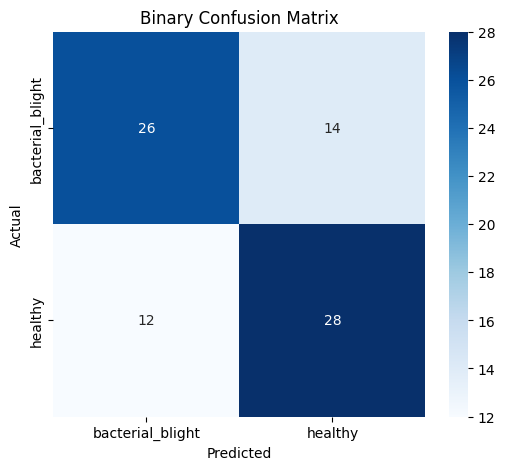

In [46]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary Confusion Matrix")
plt.show()

In [48]:
best_model = tf.keras.models.load_model("best_cassava_binary_model.keras")
best_model.save("best_cassava.final.keras")
print("Model saved successfully")

Model saved successfully


In [60]:
test_image_path = "cassava_small/bacterial_blight/1026467332.jpg" 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


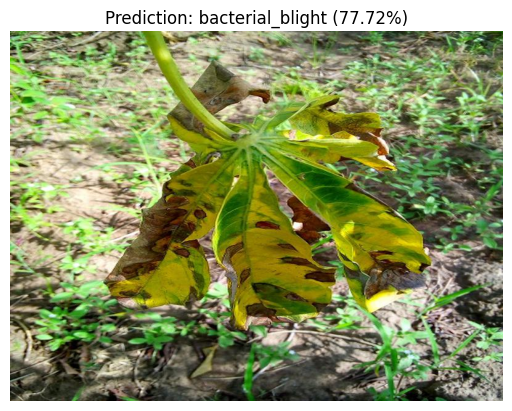

Predicted class: bacterial_blight
Confidence: 0.7771877


In [61]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(test_image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

plt.imshow(load_img(test_image_path))
plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", confidence)